In [22]:
from py_files.setup import *
setup_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. initial simulation

In [23]:
# 1. calibrate
# m = CapIncModel()
m = CapIncModel_single()
out = m.calibrate(target_elas=m.phi)

# 2. pin baseline SS first
T=25; tau0=0.0; tauT=-0.1; rho=0.85; tail=25; tau_ss=0.0 
ss0 = m.solve_steady_state(tau=tau0)


 Calibrate household: zero wage premia + target eps_nI 
targets    prem=0, prem=0, eps=0.8
------------------------------------------------------------
old        mu=0.26   =>
           log(wI/wC)=-3.05e-02

old        phi=0.75 =>
           eps=0.558
------------------------------------------------------------
new        mu=0.2499   =>
           log(wI/wC)=-1.10e-13

new        phi=0.9998 =>
           eps=0.750



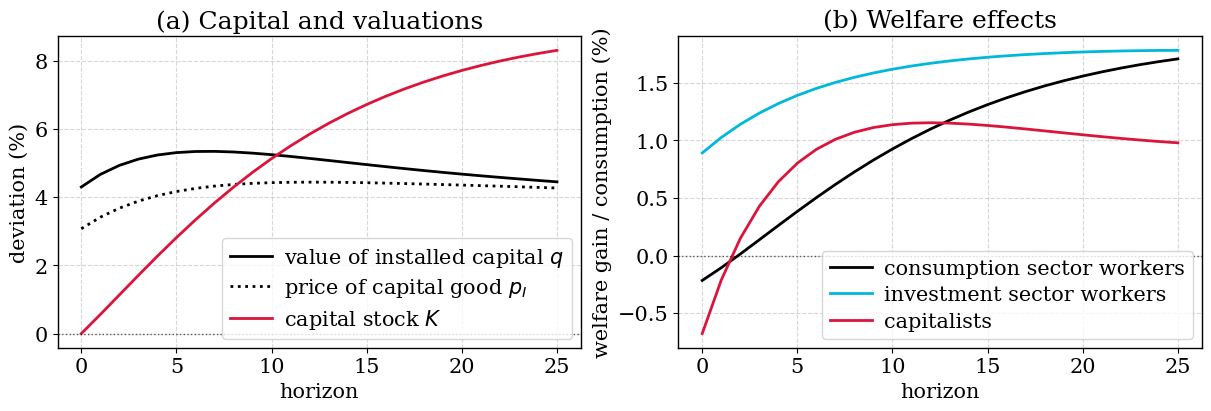

In [29]:
# 2. params and sim
net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc(
    T=T, tau0=tau0, tauT=tauT, rho=rho, tail=tail,
)

sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)

fig, (ax1, ax2), ss, sim = build_output_single.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
)


# fig, (ax1, ax2), ss, sim = build_output.welfare_effects(
#     m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
# )

In [5]:
res_elas = build_output_single.inc_elas(m, sim, tau=tau_ss) 


--------------------------------------------
 Incidence (share of total welfare gain) 
--------------------------------------------
Consumption workers     27.7%
Investment workers      48.8%
Capitalists             23.5%

--------------------------------------------
 Elasticities 
--------------------------------------------
epsS_LR        1.60
epsS_SR        0.13
epsD           1.38

--------------------------------------------
 Tax elasticities (LR GE) 
--------------------------------------------
price_elas     0.55
quant_elas     0.89
wealth_ela     1.44



In [6]:
# # 1. get empirical path
# net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc_emp(
#     tail=tail, normalized=True
# )

# tau0 = tau_long[0]

# # 2. pin baseline SS 
# ss0 = m.solve_steady_state(tau=tau0)

# # 3. simulate
# sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)

# # 4. plot
# fig, (ax1, ax2), ss, sim = build_output_single.welfare_effects(
#     m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
# )

In [7]:
# res_elas = build_output_single.inc_elas(m, sim, tau=tau_ss)

### 2. labour dynamics

*and assess the labour share*

In [8]:
# 1. initiate
gamma  = 0.8
T_solve = T + tail

# anchor baseline SS at tau0
ss0 = m.solve_steady_state(tau=tau0)
ss1 = m.solve_steady_state(tau=tauT)

In [9]:
# 1.paths
_, tau_t1_long, _, _ = shocks.perm_tc(T=T, tail=tail, tau0=tau0, tauT=tauT, rho=rho)
tau_t2_long = np.full_like(tau_t1_long, tau0)
tau_t3_long = np.full_like(tau_t1_long, tauT)
# _, tau_t4_long, _, _  = shocks.perm_tc_emp(tail=tail)

# 3. intial guesses
qg0 = np.full(T_solve + 1, ss0["q"])
qg1 = np.full(T_solve + 1, ss1["q"])

# 4. simulations
# 4.1 baseline ss
sim2 = m.solve_transition(tau_path=tau_t2_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tau0)
ls2_full = build_output_single.labour_share(m, sim2, gamma=gamma)

# 4.2 new ss
sim3 = m.solve_transition(tau_path=tau_t3_long, K0=ss1["K"],
                          q_guess_path=qg1, tau_terminal=tauT)
ls3_full = build_output_single.labour_share(m, sim3, gamma=gamma)

# 4.3 permanent shock
sim1 = m.solve_transition(tau_path=tau_t1_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tauT)
ls1_full = build_output_single.labour_share(m, sim1, gamma=gamma)

# 4.4 permanent shock (empirical)
# sim4 = m.solve_transition(tau_path=tau_t4_long, K0=ss0["K"],
#                           q_guess_path=qg0, tau_terminal=tauT)
# ls4_full = build_output_single.labour_share(m, sim4, gamma=gamma)

c:\Users\LinusLindquist\anaconda3\Lib\site-packages\scipy\optimize\_nonlin.py:374: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


In [10]:
sl = slice(0, T + 1)
ls1 = {k: np.asarray(v)[sl] for k, v in ls1_full.items()}
ls2 = {k: np.asarray(v)[sl] for k, v in ls2_full.items()}
ls3 = {k: np.asarray(v)[sl] for k, v in ls3_full.items()}
# ls4 = {k: np.asarray(v)[sl] for k, v in ls4_full.items()}
h = np.arange(T + 1)

# ncols, nrows = 4, 1

# fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3), sharex=True, constrained_layout=True)
# axes = axes.ravel()

# panels = list(var_groups.panels(gamma))   
# n_used = len(panels)

# # plot used panels
# for i, (k, ttl) in enumerate(panels):
#     ax = axes[i]
#     ax.plot(h, ls1[k] *100, lw=2, color="crimson")
#     ax.plot(h, ls2[k] *100, lw=2, color="k")
#     ax.plot(h, ls3[k] *100, lw=2, color="gray", ls=":")
#     ax.plot(h, ls4[k] *100, lw=2, color="crimson", ls=":")
#     ax.set_title(ttl)
#     # ax.set_xlabel("horizon")
#     ax.grid(True, which="both", linestyle="--", alpha=0.5)

#     ax.yaxis.set_major_locator(mticker.LinearLocator(4))
#     ax.yaxis.set_minor_locator(mticker.NullLocator())
#     ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
#     ax.tick_params(axis="y", labelsize=10)


# handles = [
#     plt.Line2D([0], [0], color="crimson", lw=2, ls="-"),
#     plt.Line2D([0], [0], color="k",       lw=2, ls="-"),
#     plt.Line2D([0], [0], color="gray",    lw=2, ls=":"),
#     plt.Line2D([0], [0], color="crimson", lw=2, ls=":"),
# ]
# labels = ["tax cut", "baseline", "new steady state", "tax cut (empirical)"]

# fig.legend(
#     handles, labels,
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.20),  # move up/down as needed
#     ncol=len(labels),
#     frameon=True
# )

# plt.show()

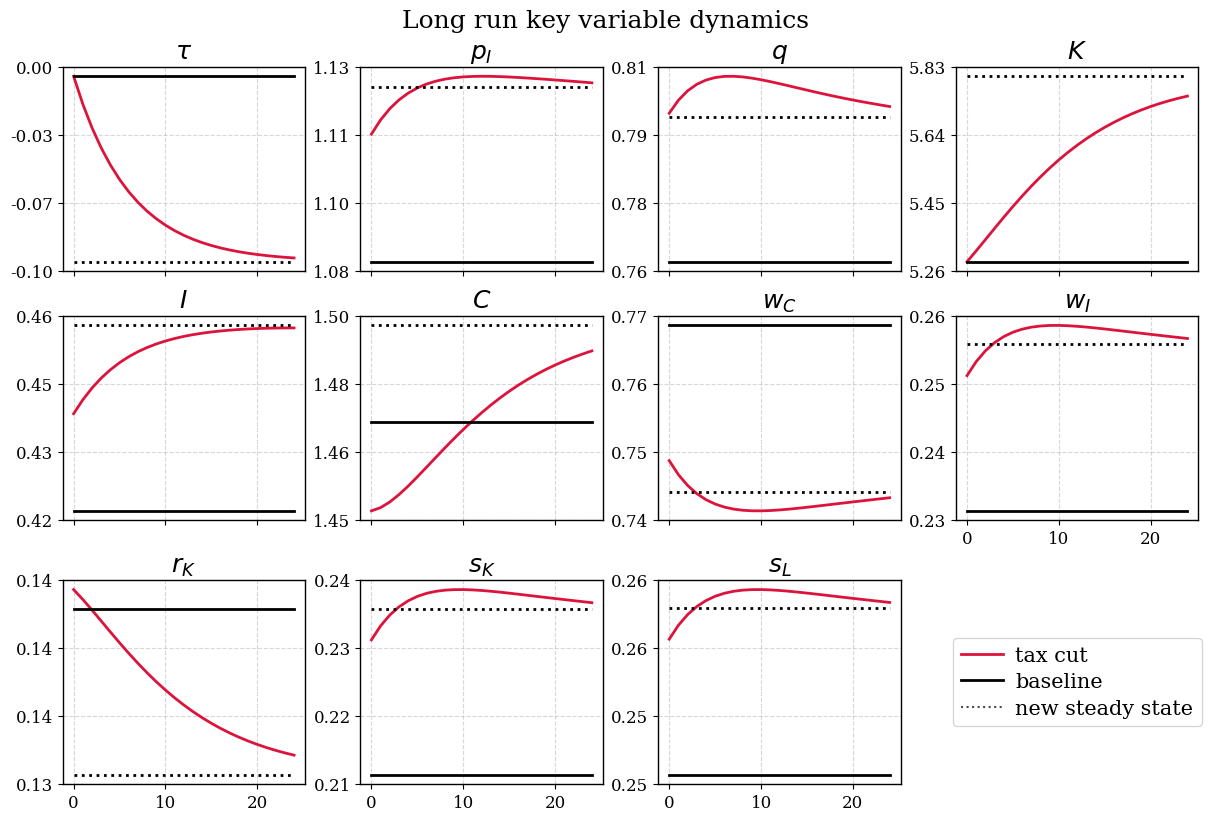

In [30]:
T_plot = T
h = np.arange(T_plot)

def trunc_pack(sim, ls):
    S = {**sim, **ls}
    return {k: np.asarray(v) for k, v in S.items()}

S1 = trunc_pack(sim1, ls1)
S2 = trunc_pack(sim2, ls2)
S3 = trunc_pack(sim3, ls3)

keys = [
    "tau", 'pI', 'q','K',
    "I","C",
    "wC","wI","rC_gross",
    "sK","sL",
    # "Y",
]
keys = [k for k in keys if k in S1 and k in S2]

ncols = 4
nrows = 3
        
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 2.7*nrows),
    sharex=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()
fig.suptitle('Long run key variable dynamics')

for i, k in enumerate(keys):
    ax = axes[i]
    y1 = S1[k][:T_plot]
    y2 = S2[k][:T_plot]
    y3 = S3[k][:T_plot]
    ax.plot(h, y1, lw=2, color="crimson")
    ax.plot(h, y2, lw=2, color="k")
    ax.plot(h, y3, lw=2, color="k", ls=":")
    ax.plot()
    
    ax.set_title(var_groups.model_var.get(k, k))
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis="y", labelsize=12)
    ax.tick_params(axis="x", labelsize=12)

for j in range(len(keys), len(axes)):
    axes[j].set_axis_off()

# if len(keys) < len(axes):
    ax_leg = axes[len(keys)]
    ax_leg.set_axis_off()
    h1 = plt.Line2D([0], [0], color="crimson", lw=2)
    h2 = plt.Line2D([0], [0], color="k",       lw=2)
    h3 = plt.Line2D([0], [0], color="k", lw=1.5, ls=":", alpha=0.7)
    ax_leg.legend([h1, h2, h3], ["tax cut", "baseline", "new steady state"],
                loc="center", frameon=True)

for col in range(ncols):
    # find the last active (visible) axis in this column
    col_axes = [axes[row * ncols + col] for row in range(nrows)
                if row * ncols + col < len(axes)]
    active = [ax for ax in col_axes if ax.get_visible() and ax.axison]
    if active:
        active[-1].tick_params(axis='x', labelbottom=True)

plt.savefig('0_output/sim_lr_cs.png', dpi=200)
plt.show()

*potentially normalise to start in zero*